# SoftWare

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
import numpy as np 
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow import keras
import numpy as np

In [28]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [31]:
#sample input
X_train.shape

(60000, 28, 28)

In [32]:
#corresponding target
y_train.shape

(60000,)

In [33]:
#normalization of the input values
X_train = X_train / 255
X_test = X_test / 255

In [34]:
#reshaping the dataset to apply cnn
X_train = X_train.reshape(-1,28,28,1)    #training set
X_test = X_test.reshape(-1,28,28,1)      #test set

In [35]:
X_train.shape

(60000, 28, 28, 1)

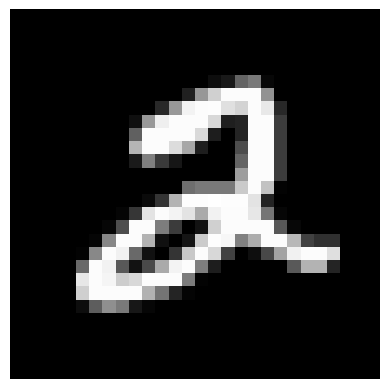

In [49]:
plt.imshow(X_train[5].reshape(28, 28), cmap='gray')
plt.axis('off')  # Optional: Hide the axis
plt.show()

In [36]:
#architecture of our model
convolutional_neural_network = models.Sequential([
    layers.Conv2D(filters=25, kernel_size=(3, 3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [37]:
#compiling and fitting our model
convolutional_neural_network.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
convolutional_neural_network.fit(X_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.8548 - loss: 0.4631
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9747 - loss: 0.0832
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9824 - loss: 0.0583
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9864 - loss: 0.0424
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9897 - loss: 0.0317
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9917 - loss: 0.0277
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9934 - loss: 0.0201
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9945 - loss: 0.0168
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9947 - loss: 0.0160
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9954 - loss: 0.0137


In [38]:
#getting the list of predictions of our model
y_predicted_by_model = convolutional_neural_network.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [39]:
#image number 341 from the X_test dataset
X_test[341]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

In [40]:
#predicted value for the sample number 341 of testing data set
np.argmax(y_predicted_by_model[341])

6

In [41]:
#verifying the value from the y_test dataset
y_test[341]

6

In [42]:
#function for calculating the accuracy of our model on testing data
corr=0
for i in range(10000):
  if(y_test[i]==np.argmax(y_predicted_by_model[i])):
    corr+=1
accuracy_model=corr/10000
print(accuracy_model*100)

98.81


# BTP

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras import layers,models
import numpy as np 
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow import keras
import pickle
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, Dropout, AveragePooling2D, Flatten, GaussianNoise, Dense, Activation

## DataSet

### Modulation(11) X SNR(20) X No._Of_Samples(500+) X 2(I/Q) X 128(Points)
### {'BPSK', 'WBFM', 'PAM4', 'QPSK', '8PSK', 'CPFSK', 'QAM16', 'AM-DSB', 'GFSK', 'QAM64', 'AM-SSB'}
### {0, 2, 4, 6, 8, 10, 12, 14, 16, 18, -20, -18, -16, -14, -12, -10, -8, -6, -4, -2}

In [2]:
import pickle

with open('2016.04C.multisnr.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Keys in the data:", data.keys())
a = []
b = []
for key in data.keys():
    a.append(key[0])
    b.append(key[1])
    print(f"Shape of {key}: {data[key].shape}")

Keys in the data: dict_keys([('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8), ('AM-SSB', 12), ('PAM4', 18), ('QAM64', -6), ('QAM16', 2), ('QAM16', -20), ('8PSK', -18), ('PAM4', -6), ('WBFM', -18), ('BPSK', 8), ('CPFSK', 10), ('WBFM', 6), ('BPSK', 4), ('BPSK', -2), ('QPSK', -20), ('CPFSK', -8), ('AM-SSB', 6), ('QAM64', -20), ('QAM16', 12), ('GFSK', -20), ('AM-SSB', -12), ('CPFSK', 0), ('AM-DSB', 6), ('BPSK', -16), ('QPSK', -6), ('8PSK', -12), ('CPFSK', -18), ('AM-DSB', -18), ('QPSK', 8), ('PAM4', 14), ('WBFM', -8), ('AM-DSB', -10), ('GFSK', 12), ('QAM64', 2), ('8PSK', -10), ('AM-SSB', -18), ('QAM64', -4), ('GFSK', -4), ('AM-DSB', 8), ('PAM4', -16), ('QPSK', -16), ('BPSK', 16), ('WBFM', -14), ('CPFSK', 16), ('WBFM', 0), ('QPSK', 6), ('BPSK', 14), ('AM-DSB', -8), ('GFSK', -10), ('CPFSK', -2), ('AM-SSB', 8), ('QAM16', 8), ('QAM16', 6), ('QAM16', -16), ('QAM64', 18), ('AM-SSB', -2), ('CPFSK', 6), ('BPSK', 0), ('BPSK', -6), ('8PSK', -14), ('CPFSK', -12), ('AM-SSB', 2), ('

In [3]:
print(set(a))
print(set(b))

{'QPSK', 'CPFSK', 'GFSK', 'QAM16', 'AM-SSB', 'WBFM', 'QAM64', 'BPSK', 'PAM4', 'AM-DSB', '8PSK'}
{0, 2, 4, 6, 8, 10, 12, 14, 16, 18, -20, -18, -16, -14, -12, -10, -8, -6, -4, -2}


## Plot Data

In [4]:
# # Visualizing
# mod_type = 'AM-DSB'

# # snr_level = 6
# # # samples available for the specified modulation type
# # unit = 0

# for snr_level in range(-20,20,2):
#     # Extract data
#     data_qpsk_18dB = data[(mod_type, snr_level)]
#     no_samples = len(data_qpsk_18dB)
#     print(no_samples)
#     no_samples = 1
    
#     for unit in range(no_samples):
        
#         sample = data_qpsk_18dB[unit]
#         # Plot I and Q components
#         plt.figure(figsize=(10, 6))
#         plt.plot(sample[0],'b', label='I (In-phase)')
#         plt.plot(sample[1],'r', label='Q (Quadrature)')
#         plt.title(f'{mod_type} Modulation at {snr_level} dB SNR')
#         plt.xlabel('Sample Index')
#         plt.ylabel('Amplitude')
#         plt.legend()
#         plt.grid(True)
#         plt.show()


## Extraction & Model

In [15]:
# Load the dataset
with open('2016.04C.multisnr.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Extract features (I and Q components) and labels
X = []
y = []
for key in data.keys():
    X.append(data[key])
    y.extend([key[0]] * len(data[key]))  # Modulation type
X = np.vstack(X)
y = np.array(y)
# print(X[0][0])
# Reshape X to match the expected input_shape for Conv2D
X = X.transpose(0, 2, 1)[:, :, np.newaxis]

# Convert modulation types to categorical labels
unique_mods = np.unique(y)
modulation_to_label = {mod: i for i, mod in enumerate(unique_mods)}
y = np.array([modulation_to_label[mod] for mod in y])
num_classes = len(unique_mods)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# Reshape X_train and X_test to (samples, 2, 128, 1)
X_train = np.transpose(X_train, (0, 3, 1, 2))
X_test = np.transpose(X_test, (0, 3, 1, 2))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (129648, 2, 128, 1)
X_test shape: (32412, 2, 128, 1)
y_train shape: (129648, 11)
y_test shape: (32412, 11)


In [10]:
# # Define the model
# model = Sequential()
# model.add(Conv2D(256, kernel_size=(1, 2), activation='relu', input_shape=(2, 128, 1)))
# model.add(Dropout(0.25))
# model.add(AveragePooling2D(pool_size=(1, 2)))
# model.add(Conv2D(96, kernel_size=(1, 4), activation='relu'))
# model.add(Dropout(0.25))
# model.add(Conv2D(64, kernel_size=(2, 6), activation='relu'))
# model.add(Dropout(0.25))
# model.add(Flatten())
# model.add(GaussianNoise(stddev=0.1))
# model.add(Dense(1024))
# model.add(Dense(256))
# model.add(Dense(64))
# model.add(Dense(num_classes))
# model.add(Activation('softmax'))

# # Compile the model
# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# model.summary()

In [11]:
# # Define the model
# model = Sequential()

# # Add Dense layers
# model.add(Flatten(input_shape=(2, 128, 1)))  # Flatten the input shape to match Dense layers
# model.add(Dense(1024, activation='relu'))
# model.add(Dropout(0.25))
# model.add(Dense(256, activation='relu'))
# model.add(Dropout(0.25))
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.25))

# # Add GaussianNoise layer
# model.add(GaussianNoise(0.1))

# # Add final Dense layers
# model.add(Dense(1024, activation='relu'))
# model.add(Dense(256, activation='relu'))
# model.add(Dense(64, activation='relu'))
# model.add(Dense(num_classes, activation='softmax'))

# # Compile the model
# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# model.summary()

In [13]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, GaussianNoise, Activation, Dropout, BatchNormalization
from keras.layers import LeakyReLU

# Define the model
model = Sequential()

# Flatten the input shape to match Dense layers
model.add(Flatten(input_shape=(2, 128, 1)))

# Add Dense layers with increased neurons and Batch Normalization
model.add(Dense(2048))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

model.add(Dense(1024))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

model.add(Dense(512))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

model.add(Dense(256))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

# Add GaussianNoise layer
model.add(GaussianNoise(0.1))

# Add final Dense layers with increased neurons
model.add(Dense(1024))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))

model.add(Dense(512))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))

model.add(Dense(256))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))

model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 2048)                │         526,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_9 (LeakyReLU)            │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1024)                │       2,098,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_10 (LeakyReLU)           │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_11 (LeakyReLU)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_12 (LeakyReLU)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 4,159,627 (15.87 MB)

 Trainable params: 4,147,851 (15.82 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [14]:
# Train the model
batch_size = 128
epochs = 50
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))

# Evaluate the model
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/50
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 117s 108ms/step - accuracy: 0.2388 - loss: 2.0145 - val_accuracy: 0.4369 - val_loss: 1.3998
Epoch 2/50
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 107s 106ms/step - accuracy: 0.4220 - loss: 1.4665 - val_accuracy: 0.5116 - val_loss: 1.2450
Epoch 3/50
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 87s 85ms/step - accuracy: 0.4631 - loss: 1.3727 - val_accuracy: 0.5255 - val_loss: 1.2135
Epoch 4/50
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 88s 86ms/step - accuracy: 0.4847 - loss: 1.3214 - val_accuracy: 0.5370 - val_loss: 1.1738
Epoch 5/50
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 93s 92ms/step - accuracy: 0.4994 - loss: 1.2857 - val_accuracy: 0.5433 - val_loss: 1.1638
Epoch 6/50
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 84s 83ms/step - accuracy: 0.5110 - loss: 1.2569 - val_accuracy: 0.5585 - val_loss: 1.1267
Epoch 7/50
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 88s 87ms/step - accuracy: 0.5216 - loss: 1.2215 - val_accuracy: 0.5568 - val_loss: 1.1184
Epoch 8/50
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 83s 82ms/step - accuracy: 0.52

In [15]:
# Make predictions
y_pred = model.predict(X_test)

1013/1013 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step


In [16]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
# for i in range(len(y_true)):
#     print(y_true[i],y_pred_classes[i])

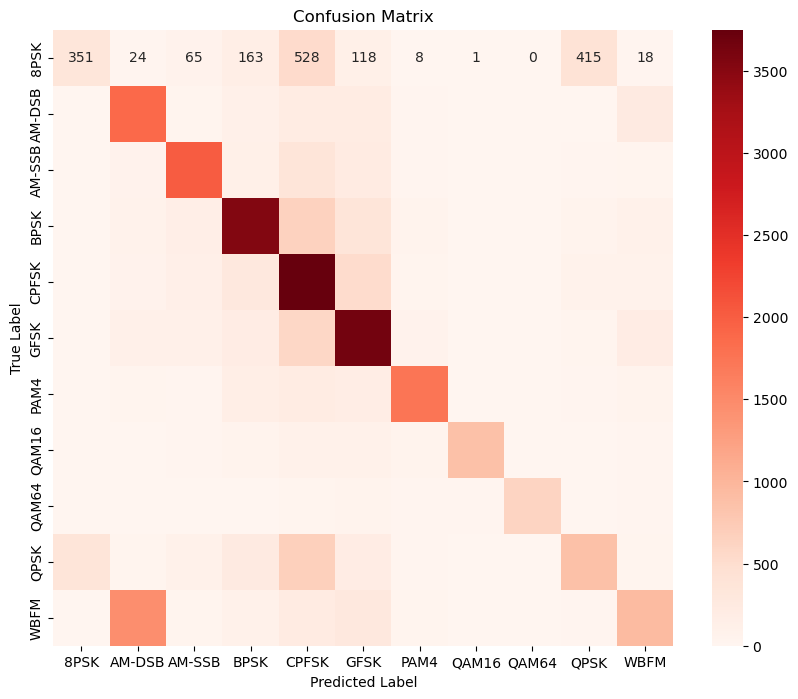

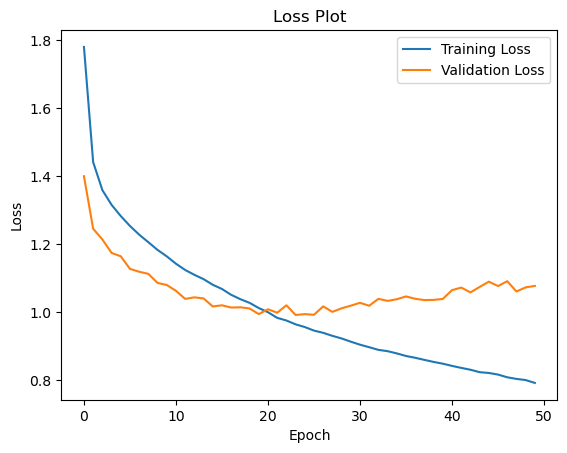

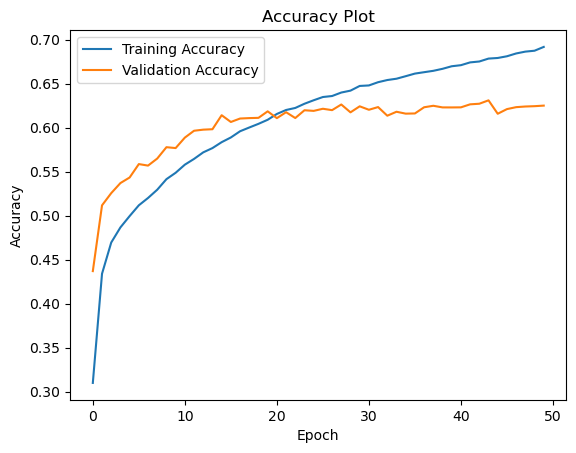

In [17]:
# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plotting confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=unique_mods, yticklabels=unique_mods)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.legend()
plt.show()

# Plot accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Plot')
plt.legend()
plt.show()

# NEW PROJECT

In [6]:
import numpy as np
from scipy.io import savemat
import random
import tqdm

# Define constants
N = 800

# Symbols sets
symbol_bpsk = np.array([-1+0j, 1+0j])
theta1 = np.cos(np.pi/8) + 1j * np.sin(np.pi/8)
theta2 = np.cos(np.pi/16) + 1j * np.sin(np.pi/16)
symbol_qpsk = theta1 * np.array([0.7071+0.7071j, -0.7071+0.7071j, 0.7071-0.7071j, -0.7071-0.7071j])
symbol_8psk = np.array([1, 0.7071+0.7071j, 1j, -0.7071+0.7071j, -1, -0.7071-0.7071j, -1j, 0.7071-0.7071j])
qam = np.array([
    -1.0000 - 1.0000j,  1.0000 - 1.0000j,  1.0000 + 1.0000j, -1.0000 + 1.0000j,
    -3.0000 - 1.0000j, -1.0000 - 3.0000j,  1.0000 - 3.0000j,  3.0000 - 1.0000j,
    3.0000 + 1.0000j,  1.0000 + 3.0000j, -1.0000 + 3.0000j, -3.0000 + 1.0000j,
    -3.0000 - 3.0000j,  3.0000 - 3.0000j,  3.0000 + 3.0000j, -3.0000 + 3.0000j
])
qam16 = qam.T

sqrt_mean = np.sqrt(np.mean(np.abs(qam16)**2))
symbol_16qam = qam16 / sqrt_mean

Pf = 0.8
Pn = 0.4

# Set variance of Rayleigh fading RV
variance = 0.1
setof_symbs = [symbol_bpsk, symbol_qpsk, symbol_8psk, symbol_16qam]

# Initialize variables
true_lbls = np.zeros(50000)
data_y = np.zeros((50000, N), dtype=complex)
all_snrs = np.zeros(50000)
all_h = np.zeros(50000)
snrs = []
data_Y = []
true_Mods = []

# Iterate over SNR range
for snr_db in tqdm.tqdm(range(-10, 21, 2)):
    snr = 10 ** (snr_db / 10)
    snr_itr = np.zeros(50000)

    for iter in range(50000):
        xr = np.random.randn()
        yi = np.random.randn()
        h = np.sqrt(variance * (xr**2 + yi**2))  # Rayleigh channel
        all_h[iter] = h
        i = random.randint(0, 3)
        true_lbls[iter] = i
        j = random.randint(0, 3)

        symb_far = setof_symbs[i]
        symb_near = setof_symbs[j]
        xf = np.random.choice(symb_far, N)
        xn = np.random.choice(symb_near, N)
        y0 = h * (np.sqrt(Pf) * xf + np.sqrt(Pn) * xn)
        ps = np.sum(np.abs(y0)**2) / len(y0)

        noisepower = ps / snr
        z = np.sqrt(noisepower * 0.5) * (np.random.randn(len(y0)) + 1j * np.random.randn(len(y0)))  # AWGN
        pn = np.sum(np.abs(z)**2) / len(z)
        y = y0 + z
        snr_y = ps / pn
        all_snrs[iter] = snr_y
        data_y[iter, :] = y
        snr_itr[iter] = snr_db

    snrs.extend(snr_itr)
    data_Y.append(data_y.copy())
    true_Mods.extend(true_lbls)

# Convert lists to numpy arrays
data_Y = np.vstack(data_Y)
true_Mods = np.array(true_Mods)
snrs = np.array(snrs)

# Save to .mat file
savemat('dataset_NOMA_N_800_1_2.mat', {'data_Y': data_Y, 'true_Mods': true_Mods, 'snrs': snrs})


SNR 20 dB: 100%|███████████████████████████████████████████████████████████████| 50000/50000 [00:06<00:00, 7423.63it/s]


OverflowError: Python int too large to convert to C long

In [1]:
import numpy as np

def generate_signal(N, Pf, Pn, h, noise_variance):
    # Generate random BPSK, QPSK, 8PSK, and 16QAM symbols
    def generate_modulated_signal(mod_type, size):
        if mod_type == 'BPSK':
            return np.random.choice([-1, 1], size=size)
        elif mod_type == 'QPSK':
            return np.random.choice([-1, 1], size=size) + 1j * np.random.choice([-1, 1], size=size)
        elif mod_type == '8PSK':
            angles = np.random.choice(np.linspace(0, 2 * np.pi, 8, endpoint=False), size=size)
            return np.cos(angles) + 1j * np.sin(angles)
        elif mod_type == '16QAM':
            real = np.random.choice([-3, -1, 1, 3], size=size)
            imag = np.random.choice([-3, -1, 1, 3], size=size)
            return real + 1j * imag
        return None
    
    # Randomly choose modulation formats
    mod_f = np.random.choice(['BPSK', 'QPSK', '8PSK', '16QAM'])
    mod_n = np.random.choice(['BPSK', 'QPSK', '8PSK', '16QAM'])
    
    # Generate modulated signals
    x_f = generate_modulated_signal(mod_f, N)
    x_n = generate_modulated_signal(mod_n, N)
    
    # Normalize to unit energy
    x_f /= np.sqrt(np.mean(np.abs(x_f)**2))
    x_n /= np.sqrt(np.mean(np.abs(x_n)**2))
    
    # Rayleigh fading channel gain
    y = h * np.sqrt(Pf) * x_f + np.sqrt(Pn) * x_n
    
    # Additive White Gaussian Noise
    noise = np.sqrt(noise_variance / 2) * (np.random.randn(N) + 1j * np.random.randn(N))
    y += noise
    
    return y, mod_f, mod_n


In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, AveragePooling2D, Flatten, Input, Concatenate, ReLU
from tensorflow.keras.models import Model

def modified_residual_block(x):
    conv1 = Conv2D(16, (1, 8), padding='same')(x)
    conv2 = Conv2D(16, (1, 1), padding='same')(x)
    
    conv1 = ReLU()(conv1)
    conv2 = ReLU()(conv2)
    
    out = Concatenate(axis=-1)([conv1, conv2])
    return out

def create_mr_cnn(input_shape):
    inputs = Input(shape=input_shape)
    
    x = Conv2D(32, (1, 8), padding='same', activation='relu')(inputs)
    x = AveragePooling2D(pool_size=(1, 2))(x)
    
    x = modified_residual_block(x)
    x = AveragePooling2D(pool_size=(1, 2))(x)
    
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    x = Dense(4, activation='softmax')(x)  # 4 classes for modulation types
    
    model = Model(inputs, x)
    return model

N=20
input_shape = (2, N, 1)
model = create_mr_cnn(input_shape)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 2, 200, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 2, 200, 32)        │             288 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_2           │ (None, 2, 100, 32)        │               0 │ conv2d_3[0][0]             │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 2, 100, 16)        │           4,112 │ average_pooling2d_2[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 2, 100, 16)        │             528 │ average_pooling2d_2[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_2 (ReLU)                │ (None, 2, 100, 16)        │               0 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_3 (ReLU)                │ (None, 2, 100, 16)        │               0 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 2, 100, 32)        │               0 │ re_lu_2[0][0],             │
│                               │                           │                 │ re_lu_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_3           │ (None, 2, 50, 32)         │               0 │ concatenate_1[0][0]        │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 3200)              │               0 │ average_pooling2d_3[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 128)               │         409,728 │ flatten_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 64)                │           8,256 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 4)                 │             260 │ dense_4[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 423,172 (1.61 MB)

 Trainable params: 423,172 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Generate synthetic dataset
def create_dataset(num_samples, N, Pf, Pn, h, noise_variance):
    X, y_f, y_n = [], [], []
    
    for _ in range(num_samples):
        y, mod_f, mod_n = generate_signal(N, Pf, Pn, h, noise_variance)
        y = np.array([np.real(y), np.imag(y)])
        X.append(y)
        y_f.append(mod_f)
        y_n.append(mod_n)
    
    X = np.array(X).reshape(-1, 2, N, 1)
    y_f = np.array(y_f)
    y_n = np.array(y_n)
    
    return X, y_f, y_n

# Dataset parameters
N = 200
num_samples = 10000
Pf, Pn = 0.8, 0.2
h = np.random.randn() + 1j * np.random.randn()
noise_variance = 0.1

X, y_f, y_n = create_dataset(num_samples, N, Pf, Pn, h, noise_variance)

# Convert labels to one-hot encoding
encoder = OneHotEncoder()
y_f = encoder.fit_transform(y_f.reshape(-1, 1)).toarray()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_f, test_size=0.4, random_state=42)

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=500, validation_data=(X_test, y_test))


UFuncTypeError: Cannot cast ufunc 'divide' output from dtype('float64') to dtype('int32') with casting rule 'same_kind'

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, AveragePooling2D, Flatten, Input, Concatenate, ReLU
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Signal generation function
def generate_signal(N, Pf, Pn, h, noise_variance):
    # Generate random BPSK, QPSK, 8PSK, and 16QAM symbols
    def generate_modulated_signal(mod_type, size):
        if mod_type == 'BPSK':
            return np.random.choice([-1, 1], size=size).astype(np.complex_)
        elif mod_type == 'QPSK':
            return (np.random.choice([-1, 1], size=size) + 1j * np.random.choice([-1, 1], size=size)).astype(np.complex_)
        elif mod_type == '8PSK':
            angles = np.random.choice(np.linspace(0, 2 * np.pi, 8, endpoint=False), size=size)
            return (np.cos(angles) + 1j * np.sin(angles)).astype(np.complex_)
        elif mod_type == '16QAM':
            real = np.random.choice([-3, -1, 1, 3], size=size)
            imag = np.random.choice([-3, -1, 1, 3], size=size)
            return (real + 1j * imag).astype(np.complex_)
        return None
    
    # Randomly choose modulation formats
    mod_f = np.random.choice(['BPSK', 'QPSK', '8PSK', '16QAM'])
    mod_n = np.random.choice(['BPSK', 'QPSK', '8PSK', '16QAM'])
    
    # Generate modulated signals
    x_f = generate_modulated_signal(mod_f, N)
    x_n = generate_modulated_signal(mod_n, N)
    
    # Normalize to unit energy
    x_f /= np.sqrt(np.mean(np.abs(x_f)**2))
    x_n /= np.sqrt(np.mean(np.abs(x_n)**2))
    
    # Rayleigh fading channel gain
    y = h * np.sqrt(Pf) * x_f + np.sqrt(Pn) * x_n
    
    # Additive White Gaussian Noise
    noise = np.sqrt(noise_variance / 2) * (np.random.randn(N) + 1j * np.random.randn(N))
    y += noise
    
    return y, mod_f, mod_n

# Modified Residual Block
def modified_residual_block(x):
    conv1 = Conv2D(16, (1, 8), padding='same')(x)
    conv2 = Conv2D(16, (1, 1), padding='same')(x)
    
    conv1 = ReLU()(conv1)
    conv2 = ReLU()(conv2)
    
    out = Concatenate(axis=-1)([conv1, conv2])
    return out

# Create MR-CNN Model
def create_mr_cnn(input_shape):
    inputs = Input(shape=input_shape)
    
    x = Conv2D(32, (1, 8), padding='same', activation='relu')(inputs)
    x = AveragePooling2D(pool_size=(1, 2))(x)
    
    x = modified_residual_block(x)
    x = AveragePooling2D(pool_size=(1, 2))(x)
    
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    x = Dense(4, activation='softmax')(x)  # 4 classes for modulation types
    
    model = Model(inputs, x)
    return model

# Dataset generation function
def create_dataset(num_samples, N, Pf, Pn, h, noise_variance):
    X, y_f = [], []
    
    for _ in range(num_samples):
        y, mod_f, _ = generate_signal(N, Pf, Pn, h, noise_variance)
        y = np.array([np.real(y), np.imag(y)])
        X.append(y)
        y_f.append(mod_f)
    
    X = np.array(X).reshape(-1, 2, N, 1)
    y_f = np.array(y_f)
    
    return X, y_f

# Dataset parameters
N = 200
num_samples = 10000
Pf, Pn = 0.8, 0.2
h = np.random.randn() + 1j * np.random.randn()
noise_variance = 0.1

X, y_f = create_dataset(num_samples, N, Pf, Pn, h, noise_variance)

# Convert labels to one-hot encoding
encoder = OneHotEncoder()
y_f = encoder.fit_transform(y_f.reshape(-1, 1)).toarray()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_f, test_size=0.4, random_state=42)

# Create and compile model
input_shape = (2, N, 1)
model = create_mr_cnn(input_shape)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=500, validation_data=(X_test, y_test))


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 2, 200, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 2, 200, 32)        │             288 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_4           │ (None, 2, 100, 32)        │               0 │ conv2d_6[0][0]             │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 2, 100, 16)        │           4,112 │ average_pooling2d_4[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 2, 100, 16)        │             528 │ average_pooling2d_4[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_4 (ReLU)                │ (None, 2, 100, 16)        │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_5 (ReLU)                │ (None, 2, 100, 16)        │               0 │ conv2d_8[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_2 (Concatenate)   │ (None, 2, 100, 32)        │               0 │ re_lu_4[0][0],             │
│                               │                           │                 │ re_lu_5[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_5           │ (None, 2, 50, 32)         │               0 │ concatenate_2[0][0]        │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_2 (Flatten)           │ (None, 3200)              │               0 │ average_pooling2d_5[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 128)               │         409,728 │ flatten_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 64)                │           8,256 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 4)                 │             260 │ dense_7[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 423,172 (1.61 MB)

 Trainable params: 423,172 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.3021 - loss: 1.3705 - val_accuracy: 0.4810 - val_loss: 1.2998
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.5017 - loss: 1.2681 - val_accuracy: 0.4978 - val_loss: 1.1678
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.5053 - loss: 1.1305 - val_accuracy: 0.4950 - val_loss: 1.0186
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.5251 - loss: 0.9886 - val_accuracy: 0.5033 - val_loss: 0.9138
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.5186 - loss: 0.8932 - val_accuracy: 0.5002 - val_loss: 0.8660
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.5262 - loss: 0.8643 - val_accuracy: 0.5005 - val_loss: 0.8490
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.5271 - loss: 0.8499 - val_accuracy: 0.5002 - val_loss: 0.8402
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.5361 - loss: 0.8337 - val_accuracy: 0.

In [6]:
import re

# Your original Verilog code
verilog_code = '''
neuron #(.numWeight(numWeight), .layerNo(layerNum), .neuronNo(0), .dataWidth(dataWidth),
         .sigmoidSize(sigmoidSize), .weightIntWidth(weightIntWidth), .actType(actType),
         .weightFile("L_3_1_b.mif"), .biasFile("dense_4_Biases_b_0.mif")) n_0 (
        .clk(clk),
        .rst(rst),
        .myinput(x_in),
        .weightValid(weightValid),
        .biasValid(biasValid),
        .weightValue(weightValue),
        .biasValue(biasValue),
        .config_layer_num(config_layer_num),
        .config_neuron_num(config_neuron_num),
        .myinputValid(x_valid),
        .out(x_out[0*dataWidth+:dataWidth]),
        .outvalid(o_valid[0])
        );

neuron #(.numWeight(numWeight), .layerNo(layerNum), .neuronNo(1), .dataWidth(dataWidth),
         .sigmoidSize(sigmoidSize), .weightIntWidth(weightIntWidth), .actType(actType),
         .weightFile("L_3_2_b.mif"), .biasFile("dense_4_Biases_b_1.mif")) n_1 (
        .clk(clk),
        .rst(rst),
        .myinput(x_in),
        .weightValid(weightValid),
        .biasValid(biasValid),
        .weightValue(weightValue),
        .biasValue(biasValue),
        .config_layer_num(config_layer_num),
        .config_neuron_num(config_neuron_num),
        .myinputValid(x_valid),
        .out(x_out[1*dataWidth+:dataWidth]),
        .outvalid(o_valid[1])
        );

neuron #(.numWeight(numWeight), .layerNo(layerNum), .neuronNo(2), .dataWidth(dataWidth),
         .sigmoidSize(sigmoidSize), .weightIntWidth(weightIntWidth), .actType(actType),
         .weightFile("L_3_3_b.mif"), .biasFile("dense_4_Biases_b_2.mif")) n_2 (
        .clk(clk),
        .rst(rst),
        .myinput(x_in),
        .weightValid(weightValid),
        .biasValid(biasValid),
        .weightValue(weightValue),
        .biasValue(biasValue),
        .config_layer_num(config_layer_num),
        .config_neuron_num(config_neuron_num),
        .myinputValid(x_valid),
        .out(x_out[2*dataWidth+:dataWidth]),
        .outvalid(o_valid[2])
        );

neuron #(.numWeight(numWeight), .layerNo(layerNum), .neuronNo(3), .dataWidth(dataWidth),
         .sigmoidSize(sigmoidSize), .weightIntWidth(weightIntWidth), .actType(actType),
         .weightFile("L_3_4_b.mif"), .biasFile("dense_4_Biases_b_3.mif")) n_3 (
        .clk(clk),
        .rst(rst),
        .myinput(x_in),
        .weightValid(weightValid),
        .biasValid(biasValid),
        .weightValue(weightValue),
        .biasValue(biasValue),
        .config_layer_num(config_layer_num),
        .config_neuron_num(config_neuron_num),
        .myinputValid(x_valid),
        .out(x_out[3*dataWidth+:dataWidth]),
        .outvalid(o_valid[3])
        );
'''

# Function to update file names
def update_file_names(verilog_code):
    # Use regex to find all occurrences of dense_128_Biases_b_<number>.mif and replace them with b_1_<number>.mif
    updated_code = re.sub(r'dense_4_Biases_b_(\d+)\.mif', r'b_3_\1.mif', verilog_code)
    return updated_code

# Update the file names in the Verilog code
updated_verilog_code = update_file_names(verilog_code)

# Print the updated Verilog code
print(updated_verilog_code)



neuron #(.numWeight(numWeight), .layerNo(layerNum), .neuronNo(0), .dataWidth(dataWidth),
         .sigmoidSize(sigmoidSize), .weightIntWidth(weightIntWidth), .actType(actType),
         .weightFile("L_3_1_b.mif"), .biasFile("b_3_0.mif")) n_0 (
        .clk(clk),
        .rst(rst),
        .myinput(x_in),
        .weightValid(weightValid),
        .biasValid(biasValid),
        .weightValue(weightValue),
        .biasValue(biasValue),
        .config_layer_num(config_layer_num),
        .config_neuron_num(config_neuron_num),
        .myinputValid(x_valid),
        .out(x_out[0*dataWidth+:dataWidth]),
        .outvalid(o_valid[0])
        );

neuron #(.numWeight(numWeight), .layerNo(layerNum), .neuronNo(1), .dataWidth(dataWidth),
         .sigmoidSize(sigmoidSize), .weightIntWidth(weightIntWidth), .actType(actType),
         .weightFile("L_3_2_b.mif"), .biasFile("b_3_1.mif")) n_1 (
        .clk(clk),
        .rst(rst),
        .myinput(x_in),
        .weightValid(weightValid),
        .